In [6]:
import numpy as np
import matplotlib.pyplot as plt

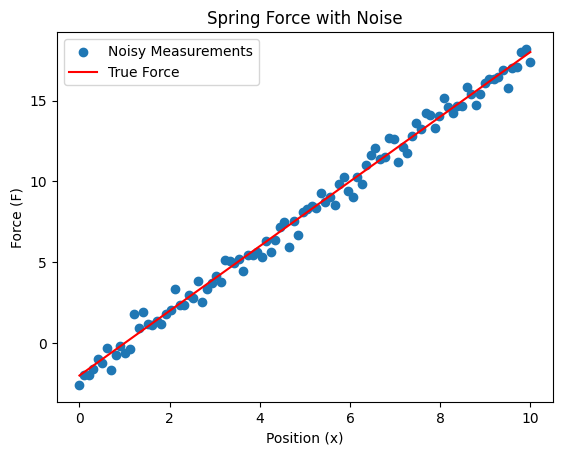

In [2]:
def elastic_force(x, k, x0):
    return k * (x - x0)

def simulate_spring(k, x0, num_points=100, noise_std=0.5):
    x = np.linspace(0, 10, num_points)
    force = elastic_force(x, k, x0)
    noise = np.random.normal(0, noise_std, size=force.shape) # Add noise to the force measurements
    return x, force + noise

# Parameters for the spring
k_true = 2.0  # Spring constant
x0_true = 1.0  # Rest position  
x, force_measurements = simulate_spring(k_true, x0_true)

plt.scatter(x, force_measurements, label='Noisy Measurements')
plt.plot(x, elastic_force(x, k_true, x0_true), label='True Force', color='red')
plt.xlabel('Position (x)')
plt.ylabel('Force (F)')
plt.title('Spring Force with Noise')
plt.legend()
plt.show()

Running MCMC...


100%|██████████| 3000/3000 [00:00<00:00, 4124.71it/s]


Done.

True  values :  k = 3.500 N/m,  sigma = 0.800 N
MCMC  median :  k = 3.599 N/m  [3.502, 3.697]  (1σ credible interval)
MCMC  median :  sigma = 0.630 N  [0.554, 0.724]


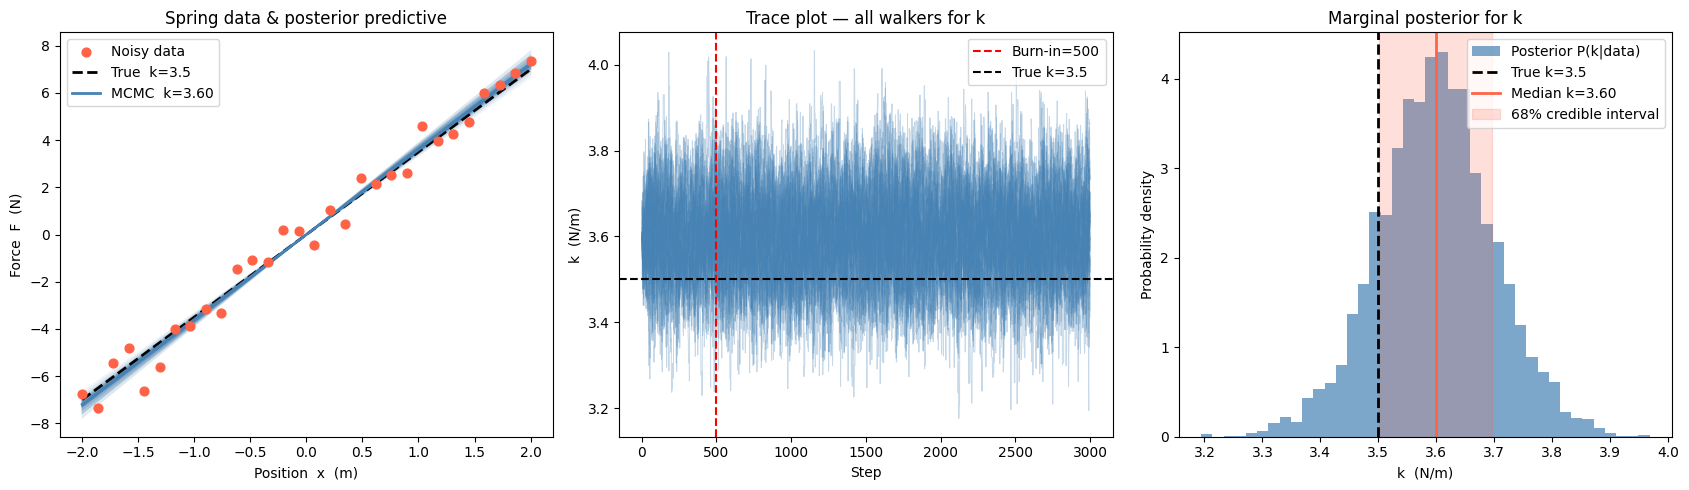

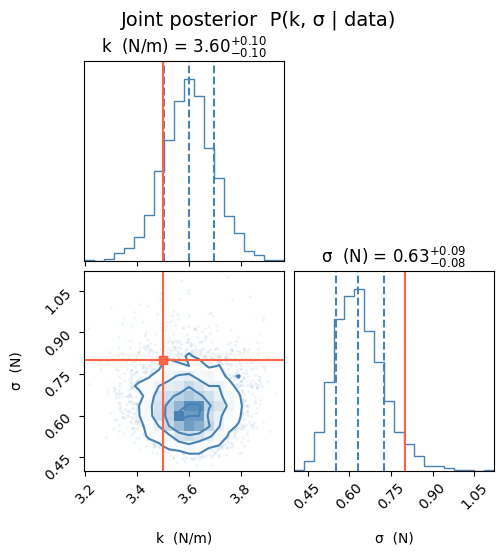


Plots saved.


In [2]:
# let's try to recover the linear behavior with MCMC sampling
"""
MCMC Sampling to Recover Spring Constant (Hooke's Law)
=======================================================
Model:  F = k * x   (Hooke's law, F = -kx but we absorb the sign into k)
        Observed data has Gaussian noise: F_obs ~ N(k*x, sigma^2)

We use emcee (affine-invariant ensemble sampler) to find the posterior:
    P(k, sigma | data) ∝ P(data | k, sigma) * P(k, sigma)
                               likelihood        prior

Install dependencies:
    pip install numpy matplotlib emcee corner
"""

import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# ── 1. Simulate spring data ───────────────────────────────────────────────────
TRUE_K     = 3.5          # N/m  — what we want MCMC to recover
TRUE_SIGMA = 0.8          # measurement noise std (N)
N_POINTS   = 30

x_data = np.linspace(-2.0, 2.0, N_POINTS)            # positions (m)
F_clean = TRUE_K * x_data                             # ideal Hooke's law
F_data  = F_clean + rng.normal(0, TRUE_SIGMA, N_POINTS)   # noisy observations

# ── 2. Define the probabilistic model ─────────────────────────────────────────

def log_prior(theta):
    """
    Prior P(theta).  We use weakly-informative priors:
      k     ~ Uniform(0, 20)   — spring constant must be positive
      sigma ~ Uniform(0, 10)   — noise std must be positive

    Returns log P(theta).  Returns -inf if params are outside prior support
    (this is how we enforce hard bounds in log-space).
    """
    k, sigma = theta
    if 0 < k < 20 and 0 < sigma < 10:
        return 0.0          # log(1) = 0  →  flat / uniform prior
    return -np.inf          # log(0) = -inf  →  zero probability


def log_likelihood(theta, x, F_obs):
    """
    Likelihood P(data | theta).
    Assumes independent Gaussian noise on each measurement:
        F_obs[i] ~ Normal(k * x[i], sigma^2)

    log L = sum_i  log[ (1/sqrt(2π σ²)) * exp(-(F_obs - k*x)² / 2σ²) ]
          = -N/2 * log(2π) - N*log(σ) - (1/2σ²) * sum((F_obs - k*x)²)
    """
    k, sigma = theta
    F_model  = k * x
    residuals = F_obs - F_model
    return -0.5 * np.sum(residuals**2 / sigma**2 + np.log(2 * np.pi * sigma**2))


def log_posterior(theta, x, F_obs):
    """
    Posterior (unnormalized):  log P(theta|data) = log P(data|theta) + log P(theta)
    This is all MCMC needs — the normalizing constant P(data) cancels out.
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf          # outside prior: reject immediately
    return lp + log_likelihood(theta, x, F_obs)


# ── 3. Run MCMC with emcee ────────────────────────────────────────────────────

N_DIM     = 2       # parameters: [k, sigma]
N_WALKERS = 32      # ensemble of parallel walkers (must be even, >= 2*ndim)
N_STEPS   = 3000    # steps per walker (first ~500 will be burn-in)
BURN_IN   = 500     # steps to discard as the chain "warms up"

# Initialise walkers near a reasonable starting point with small scatter
# (perturbing around a least-squares estimate is good practice)
k_init     = np.polyfit(x_data, F_data, 1)[0]   # quick linear regression
sigma_init = np.std(F_data - k_init * x_data)

p0 = np.array([k_init, sigma_init]) + 1e-2 * rng.standard_normal((N_WALKERS, N_DIM))
p0[:, 1] = np.abs(p0[:, 1])   # ensure sigma > 0

sampler = emcee.EnsembleSampler(
    N_WALKERS, N_DIM, log_posterior, args=(x_data, F_data)
)

print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
print("Done.\n")

# Flatten chain, discarding burn-in
flat_samples = sampler.get_chain(discard=BURN_IN, thin=15, flat=True)
# thin=15: keep every 15th sample to reduce autocorrelation

# ── 4. Results ────────────────────────────────────────────────────────────────

k_mcmc, sigma_mcmc = np.median(flat_samples, axis=0)
k_lo, k_hi         = np.percentile(flat_samples[:, 0], [16, 84])
s_lo, s_hi         = np.percentile(flat_samples[:, 1], [16, 84])

print(f"True  values :  k = {TRUE_K:.3f} N/m,  sigma = {TRUE_SIGMA:.3f} N")
print(f"MCMC  median :  k = {k_mcmc:.3f} N/m  [{k_lo:.3f}, {k_hi:.3f}]  (1σ credible interval)")
print(f"MCMC  median :  sigma = {sigma_mcmc:.3f} N  [{s_lo:.3f}, {s_hi:.3f}]")

# ── 5. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- (a) Data + fitted line ---------------------------------------------------
ax = axes[0]
x_line = np.linspace(x_data.min(), x_data.max(), 200)

# Draw 200 random posterior samples as faint lines (posterior predictive)
for s in flat_samples[rng.integers(len(flat_samples), size=200)]:
    ax.plot(x_line, s[0] * x_line, color="steelblue", alpha=0.05, lw=1)

ax.scatter(x_data, F_data, color="tomato", zorder=5, label="Noisy data", s=40)
ax.plot(x_line, TRUE_K * x_line,    "k--",  lw=2, label=f"True  k={TRUE_K}")
ax.plot(x_line, k_mcmc * x_line, "steelblue", lw=2,
        label=f"MCMC  k={k_mcmc:.2f}")
ax.set_xlabel("Position  x  (m)")
ax.set_ylabel("Force  F  (N)")
ax.set_title("Spring data & posterior predictive")
ax.legend()

# --- (b) Trace plot (walker paths) -------------------------------------------
ax = axes[1]
chain = sampler.get_chain()   # shape: (steps, walkers, ndim)
for i in range(N_WALKERS):
    ax.plot(chain[:, i, 0], alpha=0.3, lw=0.7, color="steelblue")
ax.axvline(BURN_IN, color="red", lw=1.5, ls="--", label=f"Burn-in={BURN_IN}")
ax.axhline(TRUE_K,  color="black", lw=1.5, ls="--", label=f"True k={TRUE_K}")
ax.set_xlabel("Step")
ax.set_ylabel("k  (N/m)")
ax.set_title("Trace plot — all walkers for k")
ax.legend()

# --- (c) Posterior histogram for k -------------------------------------------
ax = axes[2]
ax.hist(flat_samples[:, 0], bins=40, color="steelblue", alpha=0.7,
        density=True, label="Posterior P(k|data)")
ax.axvline(TRUE_K,   color="black", lw=2, ls="--", label=f"True k={TRUE_K}")
ax.axvline(k_mcmc,   color="tomato", lw=2, label=f"Median k={k_mcmc:.2f}")
ax.axvspan(k_lo, k_hi, alpha=0.2, color="tomato", label="68% credible interval")
ax.set_xlabel("k  (N/m)")
ax.set_ylabel("Probability density")
ax.set_title("Marginal posterior for k")
ax.legend()

plt.tight_layout()
plt.savefig("mcmc_spring_results.png", dpi=150)
plt.show()

# --- Corner plot: joint posterior of all parameters --------------------------
fig2 = corner.corner(
    flat_samples,
    labels=["k  (N/m)", "σ  (N)"],
    truths=[TRUE_K, TRUE_SIGMA],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truth_color="tomato",
    color="steelblue",
)
fig2.suptitle("Joint posterior  P(k, σ | data)", y=1.02, fontsize=14)
plt.savefig("mcmc_spring_corner.png", dpi=150)
plt.show()

print("\nPlots saved.")


PART 1: Running MCMC …


100%|██████████| 3000/3000 [00:00<00:00, 4102.09it/s]



MCMC:  k = 3.595 N/m,  sigma = 0.629 N  (true: 3.5, 0.8)

PART 2: SBI — Neural Posterior Estimation (NPE)

Generating 10000 simulations …


100%|██████████| 10000/10000 [00:00<00:00, 145331.77it/s]


Simulated theta shape : torch.Size([10000, 2])
Simulated x shape     : torch.Size([10000, 30])

Training NPE …
 Neural network successfully converged after 58 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 58
        Best validation performance: 2.2333
        -------------------------
        


Drawing 5000 posterior samples: 5073it [00:00, 309273.45it/s]           


SBI/NPE: k = 3.434 N/m,  sigma = 1.170 N  (true: 3.5, 0.8)

Plotting …


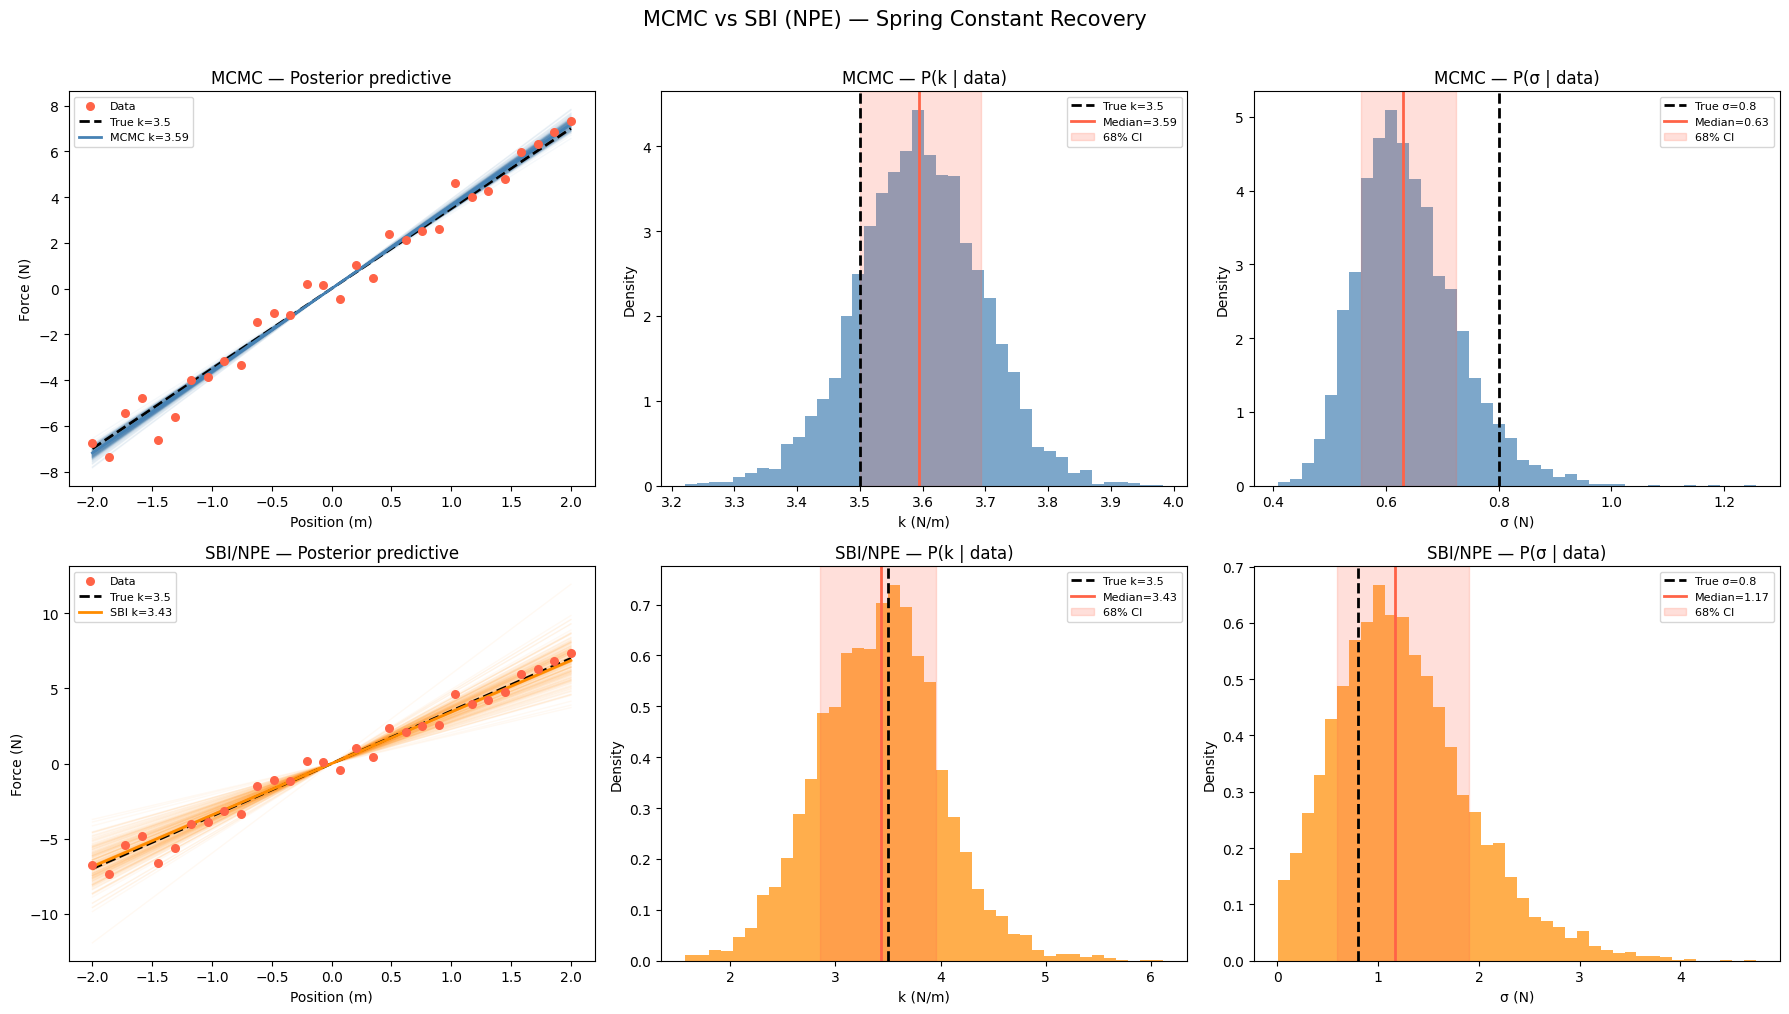

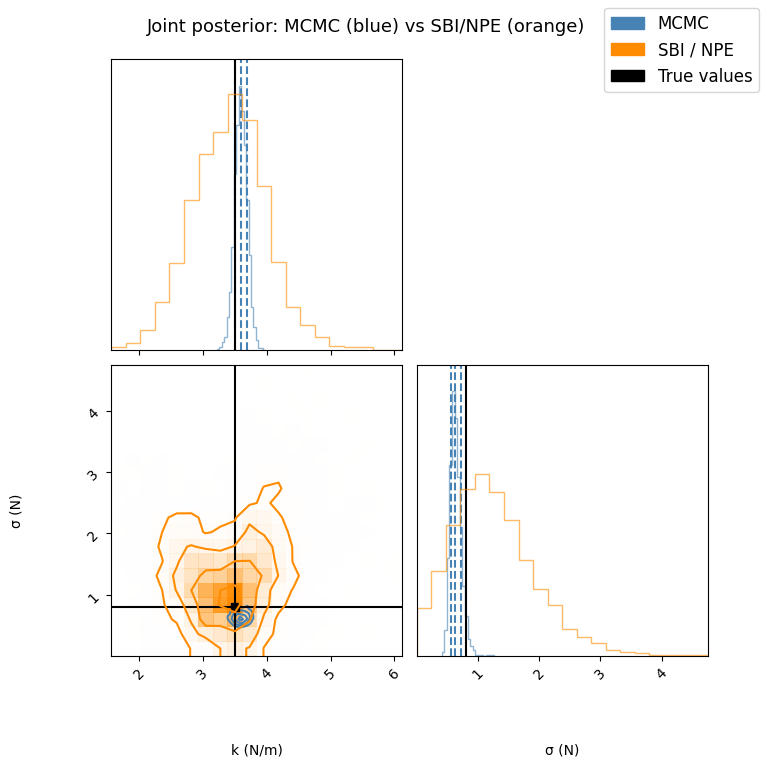


All plots saved.

── Final comparison ───────────────────────────────────────
Method       k median   σ median
True            3.500      0.800
MCMC            3.595      0.629
SBI/NPE         3.434      1.170


In [7]:
"""
SBI (Neural Posterior Estimation) vs MCMC — Spring Constant Recovery
=====================================================================

The spring model:  F_i = k * x_i + noise,   noise ~ N(0, sigma^2)
Parameters:        theta = [k, sigma]
Observation:       x_obs = vector of N force measurements at fixed positions

SBI workflow
────────────
  1. Define a PRIOR over parameters
  2. Write a SIMULATOR:  theta ──► simulated data   (no likelihood needed!)
  3. Generate many (theta, data) pairs by sampling prior + running simulator
  4. Train a neural density estimator (normalizing flow) on those pairs
     to learn:   q_phi(theta | data)  ≈  P(theta | data)
  5. At test time: pass your real observation → get the posterior instantly

Install:
    pip install sbi torch numpy matplotlib emcee corner
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee, corner
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

# ── Experiment setup (shared by MCMC and SBI) ─────────────────────────────────
TRUE_K     = 3.5        # N/m
TRUE_SIGMA = 0.8        # N
N_POINTS   = 30

x_positions = np.linspace(-2.0, 2.0, N_POINTS)   # fixed measurement positions
F_observed  = TRUE_K * x_positions + rng.normal(0, TRUE_SIGMA, N_POINTS)

# ╔══════════════════════════════════════════════════════════════════════════════
# ║  PART 1 — MCMC  (reference solution, requires explicit likelihood)
# ╚══════════════════════════════════════════════════════════════════════════════

def log_prior_mcmc(theta):
    k, sigma = theta
    return 0.0 if (0 < k < 20 and 0 < sigma < 10) else -np.inf

def log_likelihood_mcmc(theta, x, F_obs):
    k, sigma = theta
    resid = F_obs - k * x
    return -0.5 * np.sum(resid**2 / sigma**2 + np.log(2 * np.pi * sigma**2))

def log_posterior_mcmc(theta, x, F_obs):
    lp = log_prior_mcmc(theta)
    return lp + log_likelihood_mcmc(theta, x, F_obs) if np.isfinite(lp) else -np.inf

print("=" * 60)
print("PART 1: Running MCMC …")
print("=" * 60)

N_WALKERS, N_STEPS, BURN_IN = 32, 3000, 500
k0    = np.polyfit(x_positions, F_observed, 1)[0]
sig0  = np.std(F_observed - k0 * x_positions)
p0    = np.array([k0, sig0]) + 1e-2 * rng.standard_normal((N_WALKERS, 2))
p0[:, 1] = np.abs(p0[:, 1])

sampler = emcee.EnsembleSampler(
    N_WALKERS, 2, log_posterior_mcmc, args=(x_positions, F_observed)
)
sampler.run_mcmc(p0, N_STEPS, progress=True)
mcmc_samples = sampler.get_chain(discard=BURN_IN, thin=15, flat=True)

k_mcmc  = np.median(mcmc_samples[:, 0])
s_mcmc  = np.median(mcmc_samples[:, 1])
print(f"\nMCMC:  k = {k_mcmc:.3f} N/m,  sigma = {s_mcmc:.3f} N  (true: {TRUE_K}, {TRUE_SIGMA})\n")


# ╔══════════════════════════════════════════════════════════════════════════════
# ║  PART 2 — SBI with NPE (Neural Posterior Estimation)
# ╚══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("PART 2: SBI — Neural Posterior Estimation (NPE)")
print("=" * 60)

# ── Step 1: Define the prior ──────────────────────────────────────────────────
# sbi needs a torch-compatible prior.  BoxUniform is a uniform box prior.
# The prior must match the dimensionality of theta.
#
#   theta[:, 0] = k     ∈ [0, 20]
#   theta[:, 1] = sigma ∈ [0, 10]
#
# sbi will draw theta ~ prior and pass it to the simulator automatically.

prior = sbi_utils.BoxUniform(
    low  = torch.tensor([0.0,  0.0]),
    high = torch.tensor([20.0, 10.0])
)

# ── Step 2: Write the simulator ───────────────────────────────────────────────
# The simulator is the ONLY physics knowledge SBI needs.
# It takes a 1-D tensor theta = [k, sigma] and returns a 1-D tensor of data.
#
# Note: sbi calls this function for each theta sample individually.
# The output is the "observation vector" — here we use the raw force values
# at the fixed positions (shape: N_POINTS,).  No likelihood is ever needed.

x_torch = torch.tensor(x_positions, dtype=torch.float32)

def spring_simulator(theta: torch.Tensor) -> torch.Tensor:
    """
    theta can be:
      - shape (2,)        → single sample  [k, sigma]
      - shape (batch, 2)  → batch of samples
    sbi passes batches, so we must handle both cases.
    """
    # Ensure theta is always 2-D: (batch_size, 2)
    if theta.dim() == 1:
        theta = theta.unsqueeze(0)   # (2,) → (1, 2)

    k     = theta[:, 0]              # shape: (batch,)
    sigma = theta[:, 1]              # shape: (batch,)

    # Vectorised: broadcast (batch, 1) * (1, N_POINTS) → (batch, N_POINTS)
    F_sim = k.unsqueeze(1) * x_torch.unsqueeze(0) \
            + sigma.unsqueeze(1) * torch.randn(theta.shape[0], N_POINTS)

    return F_sim    # shape: (batch, N_POINTS)

# ── Step 3: Generate simulations ──────────────────────────────────────────────
# simulate_for_sbi is a helper that:
#   1. Draws N_SIM theta values from the prior
#   2. Runs spring_simulator(theta) for each one
#   3. Returns tensors theta_sim (N_SIM, 2)  and  x_sim (N_SIM, N_POINTS)
#
# N_SIM = training budget

N_SIM = 10000
print(f"\nGenerating {N_SIM} simulations …")

theta_sim, x_sim = simulate_for_sbi(
    simulator = spring_simulator,
    proposal  = prior,
    num_simulations = N_SIM,
)
# theta_sim : (5000, 2)  — the sampled [k, sigma] pairs
# x_sim     : (5000, 30) — the corresponding simulated force vectors
print(f"Simulated theta shape : {theta_sim.shape}")
print(f"Simulated x shape     : {x_sim.shape}")

# ── Step 4: Train the neural density estimator ────────────────────────────────
# NPE (Neural Posterior Estimation) trains a conditional normalizing flow:
#
#       q_phi(theta | x_obs)  ≈  P(theta | x_obs)
#
# Internally sbi builds a neural network that takes x_obs as input and
# outputs the parameters of a flexible density over theta.
# It is trained by maximising  E[ log q_phi(theta | x) ]  over the simulations.
#
# The default density estimator is a Masked Autoregressive Flow (MAF) —
# a type of normalizing flow that can represent complex, multi-modal posteriors.

print("\nTraining NPE …")
inference = NPE(prior=prior)
inference.append_simulations(theta_sim, x_sim)   # register the training data
density_estimator = inference.train(            # train the normalizing flow
    training_batch_size = 256,
    max_num_epochs      = 100,                  # early-stopping will kick in
    show_train_summary  = True,
)

# ── Step 5: Build the posterior for your actual observation ───────────────────
# This is the "amortized" payoff: pass the real F_observed vector and
# immediately get a posterior object — no new training, no MCMC chain.

posterior = inference.build_posterior(density_estimator)

x_obs_torch = torch.tensor(F_observed, dtype=torch.float32)

# Draw samples from the learned posterior q_phi(theta | x_obs)
N_POSTERIOR = 5_000
sbi_samples = posterior.sample(
    (N_POSTERIOR,),
    x = x_obs_torch,
)                                       # shape: (N_POSTERIOR, 2)
sbi_samples_np = sbi_samples.numpy()

k_sbi  = np.median(sbi_samples_np[:, 0])
s_sbi  = np.median(sbi_samples_np[:, 1])
print(f"\nSBI/NPE: k = {k_sbi:.3f} N/m,  sigma = {s_sbi:.3f} N  (true: {TRUE_K}, {TRUE_SIGMA})")

# ── Step 6: Posterior predictive check ───────────────────────────────────────
# Draw random theta from the posterior and run the simulator to check
# that the inferred model actually reproduces the observed data.

pp_samples = sbi_samples_np[rng.integers(N_POSTERIOR, size=200)]


# Side-by-side comparison plots

print("\nPlotting …")
x_line = np.linspace(x_positions.min(), x_positions.max(), 200)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("MCMC vs SBI (NPE) — Spring Constant Recovery", fontsize=15, y=1.01)

# ── Row 1: MCMC ───────────────────────────────────────────────────────────────
# (a) Posterior predictive
ax = axes[0, 0]
mcmc_draw = mcmc_samples[rng.integers(len(mcmc_samples), size=200)]
for s in mcmc_draw:
    ax.plot(x_line, s[0] * x_line, color="steelblue", alpha=0.05, lw=1)
ax.scatter(x_positions, F_observed, color="tomato", zorder=5, s=30, label="Data")
ax.plot(x_line, TRUE_K * x_line, "k--", lw=2, label=f"True k={TRUE_K}")
ax.plot(x_line, k_mcmc * x_line, "steelblue", lw=2, label=f"MCMC k={k_mcmc:.2f}")
ax.set(xlabel="Position (m)", ylabel="Force (N)", title="MCMC — Posterior predictive")
ax.legend(fontsize=8)

# (b) Marginal posterior for k
ax = axes[0, 1]
ax.hist(mcmc_samples[:, 0], bins=40, density=True, color="steelblue", alpha=0.7)
ax.axvline(TRUE_K,  color="black", lw=2, ls="--", label=f"True k={TRUE_K}")
ax.axvline(k_mcmc, color="tomato", lw=2, label=f"Median={k_mcmc:.2f}")
lo, hi = np.percentile(mcmc_samples[:, 0], [16, 84])
ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
ax.set(xlabel="k (N/m)", ylabel="Density", title="MCMC — P(k | data)")
ax.legend(fontsize=8)

# (c) Marginal posterior for sigma
ax = axes[0, 2]
ax.hist(mcmc_samples[:, 1], bins=40, density=True, color="steelblue", alpha=0.7)
ax.axvline(TRUE_SIGMA, color="black", lw=2, ls="--", label=f"True σ={TRUE_SIGMA}")
ax.axvline(s_mcmc, color="tomato", lw=2, label=f"Median={s_mcmc:.2f}")
lo, hi = np.percentile(mcmc_samples[:, 1], [16, 84])
ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
ax.set(xlabel="σ (N)", ylabel="Density", title="MCMC — P(σ | data)")
ax.legend(fontsize=8)

# ── Row 2: SBI ────────────────────────────────────────────────────────────────
# (d) Posterior predictive
ax = axes[1, 0]
for s in pp_samples:
    ax.plot(x_line, s[0] * x_line, color="darkorange", alpha=0.05, lw=1)
ax.scatter(x_positions, F_observed, color="tomato", zorder=5, s=30, label="Data")
ax.plot(x_line, TRUE_K * x_line, "k--", lw=2, label=f"True k={TRUE_K}")
ax.plot(x_line, k_sbi * x_line, "darkorange", lw=2, label=f"SBI k={k_sbi:.2f}")
ax.set(xlabel="Position (m)", ylabel="Force (N)", title="SBI/NPE — Posterior predictive")
ax.legend(fontsize=8)

# (e) Marginal posterior for k
ax = axes[1, 1]
ax.hist(sbi_samples_np[:, 0], bins=40, density=True, color="darkorange", alpha=0.7)
ax.axvline(TRUE_K, color="black", lw=2, ls="--", label=f"True k={TRUE_K}")
ax.axvline(k_sbi, color="tomato", lw=2, label=f"Median={k_sbi:.2f}")
lo, hi = np.percentile(sbi_samples_np[:, 0], [16, 84])
ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
ax.set(xlabel="k (N/m)", ylabel="Density", title="SBI/NPE — P(k | data)")
ax.legend(fontsize=8)

# (f) Marginal posterior for sigma
ax = axes[1, 2]
ax.hist(sbi_samples_np[:, 1], bins=40, density=True, color="darkorange", alpha=0.7)
ax.axvline(TRUE_SIGMA, color="black", lw=2, ls="--", label=f"True σ={TRUE_SIGMA}")
ax.axvline(s_sbi, color="tomato", lw=2, label=f"Median={s_sbi:.2f}")
lo, hi = np.percentile(sbi_samples_np[:, 1], [16, 84])
ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
ax.set(xlabel="σ (N)", ylabel="Density", title="SBI/NPE — P(σ | data)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sbi_vs_mcmc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Corner plot: MCMC vs SBI overlaid ────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(8, 8))
# We use corner manually to overlay both posteriors
labels = ["k (N/m)", "σ (N)"]
corner.corner(
    mcmc_samples, labels=labels, fig=fig2,
    color="steelblue", truths=[TRUE_K, TRUE_SIGMA],
    truth_color="black", quantiles=[0.16, 0.5, 0.84],
    plot_density=True, plot_datapoints=False,
    hist_kwargs={"alpha": 0.6},
)
corner.corner(
    sbi_samples_np, labels=labels, fig=fig2,
    color="darkorange",
    plot_density=True, plot_datapoints=False,
    hist_kwargs={"alpha": 0.6},
)
# Manual legend
from matplotlib.patches import Patch
fig2.legend(
    handles=[Patch(color="steelblue", label="MCMC"),
             Patch(color="darkorange", label="SBI / NPE"),
             Patch(color="black",     label="True values")],
    loc="upper right", fontsize=12
)
fig2.suptitle("Joint posterior: MCMC (blue) vs SBI/NPE (orange)", fontsize=13)
plt.savefig("sbi_vs_mcmc_corner.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll plots saved.")
print("\n── Final comparison ───────────────────────────────────────")
print(f"{'Method':<10} {'k median':>10} {'σ median':>10}")
print(f"{'True':<10} {TRUE_K:>10.3f} {TRUE_SIGMA:>10.3f}")
print(f"{'MCMC':<10} {k_mcmc:>10.3f} {s_mcmc:>10.3f}")
print(f"{'SBI/NPE':<10} {k_sbi:>10.3f} {s_sbi:>10.3f}")